# Calibration pass — summary figures

Renders the figures for `docs/2026-08-19-calibration-pass-findings.md`.

**Kernel: `du`**, which has pandas, seaborn and matplotlib. Not `docparse` — that
environment is deliberately five pure-Python packages and the pipeline depends on
it staying that way.

Everything is derived from the `scores_*.json` reports. Predictions are gitignored
and machine-specific, so an analysis that read them would run only on the machine
that produced them.

Each figure is written as **SVG** for the web and slides, and **PNG** because
pandoc does not embed SVG into `.docx` — it wants EMF, and quietly drops or
rasterises SVG instead.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

REPO = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(REPO))

# The repo is not installed as a package, so the path insert above must
# precede this import.
from analysis import figures  # noqa: E402

figures.apply_style()
FIGURES = REPO / "docs" / "figures"
print(REPO)

/Users/tod/Desktop/doc-parsing-corpus


## Load

Pass the reports oldest first; a later one wins on a system-name collision, which
is how the superseded prompted runs are replaced by the current ones.

`load` refuses reports that scored different corpora. That is fatal rather than a
warning because a figure mixing two vintages looks entirely normal.

In [2]:
REPORTS = [
    REPO / "scores_parsers.json",  # MinerU — reads no prompt
    REPO / "scores_v4.json",  # gemma 12B 4-bit, InternVL — current prompt
    REPO / "scores_control.json",  # the BF16 precision controls
    REPO / "scores_31b.json",  # the capacity control
]
available = [p for p in REPORTS if p.exists()]
missing = [p.name for p in REPORTS if not p.exists()]
if missing:
    print(f"not yet scored, skipping: {', '.join(missing)}")

# scores_parsers.json also holds Docling, which was dropped from the study;
# figures.EXCLUDED removes it here rather than in each chart, so a new figure
# cannot restore it by forgetting to filter. Its median CER of 0.41 against a
# mean of 1.65 is repetition loops, and it compresses every other system into
# the top band of every axis these charts use.
documents = figures.load(*available)
print(f"{len(documents)} document rows across {documents.system.nunique()} systems")
print(f"excluded: {', '.join(sorted(figures.EXCLUDED))}")
documents.groupby("system").size().sort_index()

990 document rows across 6 systems
excluded: Docling


system
InternVL3.5-8B        165
MinerU                165
gemma 12B 4-bit       165
gemma 12B BF16        165
gemma 12B BF16 QAT    165
gemma 31B 4-bit       165
dtype: int64

## The numbers behind the figures

Medians, not means: a handful of catastrophic pages distort the averages badly,
and quoting means alone misdescribes every system here.

**`digit recall` and `placement` are separate questions and rank systems
differently.** The first asks whether the value reached the output at all; the
second, of the values that did, how many sit under the heading the page puts
them under. A system can be good at one and bad at the other, and `usable` — the
only figure a consumer can act on — is their product.

In [3]:
summary = (
    documents.groupby("system")
    .apply(
        lambda g: pd.Series(
            {
                "median nCER": g.normalised_cer.median(),
                "median sCER": g.strict_cer.median(),
                "gap": (g.strict_cer - g.normalised_cer).median(),
                # Dimension 1: is the value on the page present anywhere in the
                # output? Position is discarded.
                "digit recall": g.read.sum() / g.amounts.sum(),
                # Dimension 2, conditional on the first: of what WAS read, how
                # much sits under the right heading. Dividing by amounts instead
                # would fold a reading failure into a placement score.
                "placement": g.placed.sum() / g.read.sum(),
                # Their product, and the number to act on.
                "usable": g.usable.sum() / g.amounts.sum(),
                "rows aligned": g.aligned.sum() / g.truth_rows.sum(),
                "width ok": g.columns_match.sum() / len(g),
            }
        ),
        include_groups=False,
    )
    .sort_values("usable", ascending=False)
)
summary.style.format("{:.4f}")

,median nCER,median sCER,gap,digit recall,placement,usable,rows aligned,width ok
system,,,,,,,,
gemma 31B 4-bit,0.0000,0.0161,0.0134,0.9964,0.9956,0.9920,0.9571,0.9818
gemma 12B BF16,0.0026,0.0317,0.0139,0.9600,0.9933,0.9537,0.7621,0.9515
gemma 12B BF16 QAT,0.0050,0.0359,0.0138,0.9501,0.9975,0.9477,0.7411,1.0000
gemma 12B 4-bit,0.0081,0.0382,0.0136,0.9129,0.9895,0.9033,0.6778,0.9879
InternVL3.5-8B,0.0420,0.2119,0.1630,0.9449,0.9188,0.8682,0.6698,0.9212
MinerU,0.0403,0.4277,0.3917,0.9093,0.9332,0.8486,0.6239,0.6606


In [4]:
# Bank statements alone — the only genuinely hard tables in the corpus. Invoices
# are near-saturated and receipts are a two-column list, so an average over the
# three describes none of them.
#
# The two dimensions multiply: read × placement = usable. Reading them apart is
# what shows that the 12B gemma and InternVL fail in opposite directions while
# landing a few points apart on the figure either of them would be quoted by.
statements = documents[documents.doc_type == "bank_statements"]
statements.groupby("system").apply(
    lambda g: pd.Series(
        {
            "amounts": g.amounts.sum(),
            "read": g.read.sum() / g.amounts.sum(),
            "placement": g.placed.sum() / g.read.sum(),
            "usable": g.usable.sum() / g.amounts.sum(),
            "misread": g.misread.sum(),
            "dropped": g.dropped.sum(),
            "invented": g.invented.sum(),
        }
    ),
    include_groups=False,
).sort_values("usable", ascending=False).style.format(
    {"amounts": "{:.0f}", "misread": "{:.0f}", "dropped": "{:.0f}", "invented": "{:.0f}"},
    precision=4,
)

,amounts,read,placement,usable,misread,dropped,invented
system,,,,,,,
gemma 31B 4-bit,2011,0.9955,0.9945,0.9901,3,2,2
gemma 12B BF16,2011,0.9518,0.9916,0.9438,52,87,84
gemma 12B BF16 QAT,2011,0.9388,0.9968,0.9359,74,66,61
MinerU,2011,0.9786,0.9228,0.9030,0,15,7
gemma 12B 4-bit,2011,0.8951,0.9867,0.8831,101,143,127
InternVL3.5-8B,2011,0.9483,0.8993,0.8528,2,76,1


## What each configuration delivered

Read from the runs' own `_timing.json` sidecars, on the 2×L4 production has.
Each system is timed the way its weights allow it to be served: weights that fit
a card get `dp=2`, two independent replicas; weights that do not get `tp=2`, one
engine sharded across both.

**A rate flagged `floor` includes model load.** MinerU is invoked as a
subprocess per chunk and reloads each time, so there is no generate-only
interval to time — unlike the engine-driven runners. Its true rate is higher by
an unmeasured margin, and comparing it unflagged would understate it.

In [5]:
timings = figures.throughput(REPO / "runs_throughput")
if timings:
    usable_rate = (
        documents[documents.doc_type == "bank_statements"]
        .groupby("system")[["usable", "amounts"]]
        .sum()
        .pipe(lambda f: f.usable / f.amounts)
    )
    deployment = (
        pd.DataFrame(
            [
                {
                    "system": name,
                    "deployment": t["deployment"],
                    "images/min": t["images_per_minute"],
                    "per card": t["images_per_minute_per_card"],
                    "floor": t["includes_model_load"],
                    "usable (statements)": usable_rate.get(name),
                }
                for name, t in timings.items()
            ]
        )
        .set_index("system")
        .sort_values("per card", ascending=False)
    )
    display(deployment)
else:
    print("no runs_throughput/*/_timing*.json — nothing timed on this machine")

,deployment,images/min,per card,floor,usable (statements)
system,,,,,
MinerU,dp=2,22.20,11.10,True,0.903033
gemma 12B 4-bit,dp=2,13.79,6.90,False,0.883143
InternVL3.5-8B,dp=2,5.47,2.74,False,0.852810
gemma 31B 4-bit,tp=2,5.33,2.67,False,0.990055


## Figures

Each returns the paths it wrote.

In [6]:
written = figures.all_figures(documents, FIGURES, REPO / "runs_throughput")
for path in written:
    print(path.relative_to(REPO), f"{path.stat().st_size // 1024} KB")

docs/figures/01-convention-cost.svg 56 KB
docs/figures/01-convention-cost.png 88 KB
docs/figures/02-numeric-fidelity.svg 54 KB
docs/figures/02-numeric-fidelity.png 91 KB
docs/figures/03-structure-tradeoff.svg 53 KB
docs/figures/03-structure-tradeoff.png 99 KB
docs/figures/04-by-document-type.svg 51 KB
docs/figures/04-by-document-type.png 81 KB
docs/figures/05-pareto-cost-of-accuracy.svg 64 KB
docs/figures/05-pareto-cost-of-accuracy.png 119 KB


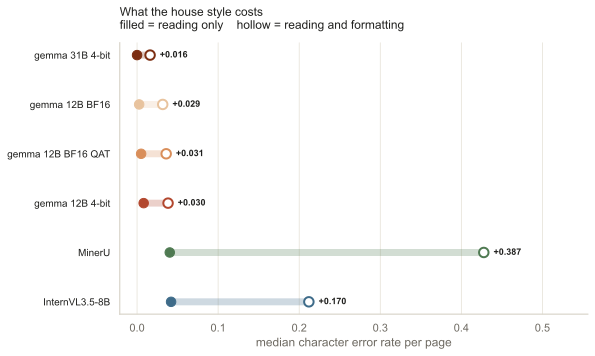

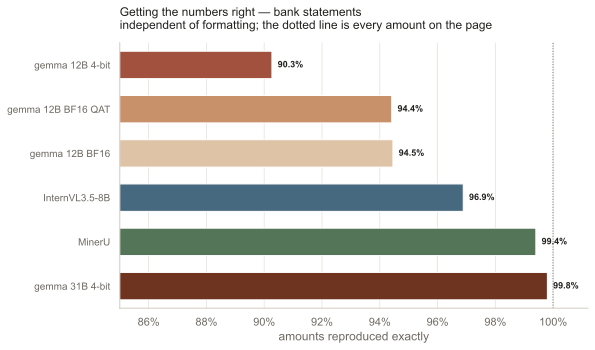

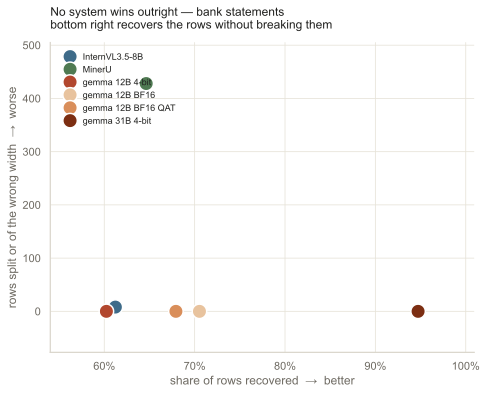

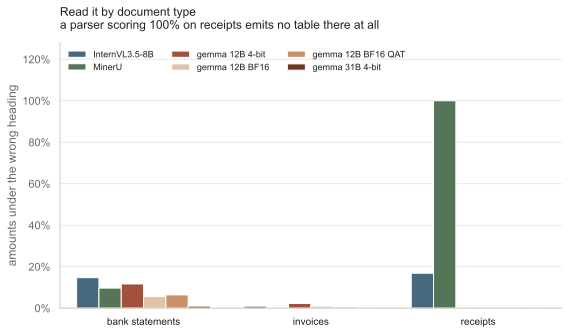

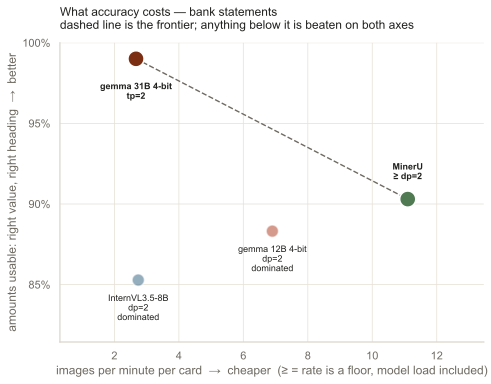

In [7]:
from IPython.display import SVG, display

for path in sorted(FIGURES.glob("*.svg")):
    display(SVG(filename=str(path)))

## Download

Click to save. SVG for the web and slides; PNG for the `.docx` path.

In [8]:
from IPython.display import FileLinks

FileLinks(str(FIGURES.relative_to(REPO)))

Path ( docs/figures ) doesn't exist. It may still be in the process of being generated, or you may have the incorrect path.